In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalTemperatures.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByState.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCountry.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCity.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByMajorCity.csv


In [2]:
!pip install pykan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 3.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from kan import KAN
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
import time
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All imports successful!
PyTorch version: 2.10.0+cu128
CUDA available: True


In [4]:
import os
import glob

# Find all CSV files in kaggle input
for f in glob.glob('/kaggle/input/**/*.csv', recursive=True):
    print(f)

/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalTemperatures.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByState.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCountry.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCity.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByMajorCity.csv


In [5]:
df = pd.read_csv('/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCity.csv')

print("Shape:", df.shape)
print("\nNull values:\n", df.isnull().sum())
print("\nSample:")
df.head()

Shape: (8599212, 7)

Null values:
 dt                                    0
AverageTemperature               364130
AverageTemperatureUncertainty    364130
City                                  0
Country                               0
Latitude                              0
Longitude                             0
dtype: int64

Sample:


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


In [6]:
# Drop nulls
df.dropna(inplace=True)

# Parse datetime
df['dt'] = pd.to_datetime(df['dt'])
df['year'] = df['dt'].dt.year
df['month'] = df['dt'].dt.month

# Parse coordinates — they come as "33.33N" / "12.5W" format
def parse_coord(coord):
    if coord[-1] in ['N', 'E']:
        return float(coord[:-1])
    else:
        return -float(coord[:-1])

df['lat'] = df['Latitude'].apply(parse_coord)
df['lon'] = df['Longitude'].apply(parse_coord)

# Focus on post-1900 for cleaner data
df = df[df['year'] >= 1900]

# Cyclical encoding for month — so model knows Dec and Jan are close
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Distance from equator — key spatial feature
df['abs_lat'] = np.abs(df['lat'])

# Hemisphere flag
df['is_northern'] = (df['lat'] > 0).astype(int)

print("Shape after cleaning:", df.shape)
print("\nFeature sample:")
df[['lat', 'lon', 'month_sin', 'month_cos', 'abs_lat', 'is_northern', 'year', 'AverageTemperature']].head()

Shape after cleaning: (4788080, 15)

Feature sample:


,lat,lon,month_sin,month_cos,abs_lat,is_northern,year,AverageTemperature
1874,57.05,10.33,0.500000,8.660254e-01,57.05,1,1900,-0.989
1875,57.05,10.33,0.866025,5.000000e-01,57.05,1,1900,-2.799
1876,57.05,10.33,1.000000,6.123234e-17,57.05,1,1900,0.592
1877,57.05,10.33,0.866025,-5.000000e-01,57.05,1,1900,4.630
1878,57.05,10.33,0.500000,-8.660254e-01,57.05,1,1900,9.576


In [7]:
features = ['lat', 'lon', 'month_sin', 'month_cos', 'abs_lat', 'is_northern', 'year']
target = 'AverageTemperature'

X = df[features].values
y = df[target].values

# Scale
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

# Sample 50k rows — good balance of speed and representativeness
np.random.seed(42)
idx = np.random.choice(len(X_scaled), 50000, replace=False)
X_s, y_s = X_scaled[idx], y_scaled[idx]

X_train, X_test, y_train, y_test = train_test_split(
    X_s, y_s, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {features}")

Training samples: 40000
Test samples: 10000
Features: ['lat', 'lon', 'month_sin', 'month_cos', 'abs_lat', 'is_northern', 'year']


In [8]:
start = time.time()

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=300,
    random_state=42,
    early_stopping=True,
    verbose=True
)

mlp.fit(X_train, y_train)
mlp_time = time.time() - start

mlp_preds = mlp.predict(X_test)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_preds))
mlp_r2 = r2_score(y_test, mlp_preds)

print(f"\nMLP Results:")
print(f"RMSE: {mlp_rmse:.4f}")
print(f"R²:   {mlp_r2:.4f}")
print(f"Time: {mlp_time:.2f}s")

Iteration 1, loss = 0.12005127
Validation score: 0.885116
Iteration 2, loss = 0.05457870
Validation score: 0.900889
Iteration 3, loss = 0.04908215
Validation score: 0.908821
Iteration 4, loss = 0.04575841
Validation score: 0.913133
Iteration 5, loss = 0.04335929
Validation score: 0.916906
Iteration 6, loss = 0.04197694
Validation score: 0.918387
Iteration 7, loss = 0.04069505
Validation score: 0.921382
Iteration 8, loss = 0.03949017
Validation score: 0.924181
Iteration 9, loss = 0.03846461
Validation score: 0.922631
Iteration 10, loss = 0.03785222
Validation score: 0.926337
Iteration 11, loss = 0.03707031
Validation score: 0.928332
Iteration 12, loss = 0.03612849
Validation score: 0.929347
Iteration 13, loss = 0.03577866
Validation score: 0.930356
Iteration 14, loss = 0.03511567
Validation score: 0.932172
Iteration 15, loss = 0.03447683
Validation score: 0.933152
Iteration 16, loss = 0.03377695
Validation score: 0.932387
Iteration 17, loss = 0.03375558
Validation score: 0.933122
Iterat

In [9]:
# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
X_test_t  = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train)
y_test_t  = torch.FloatTensor(y_test)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t.unsqueeze(1),
    'test_input':  X_test_t,
    'test_label':  y_test_t.unsqueeze(1)
}

# Architecture: 7 inputs → 8 hidden → 1 output
model = KAN(width=[7, 8, 1], grid=5, k=3, seed=42)

start = time.time()

# Correct API for pykan 0.2.8
results = model.fit(
    dataset,
    opt="LBFGS",
    steps=100,
    lamb=0.001,
    lamb_entropy=2.0,
    loss_fn=torch.nn.MSELoss(),
    metrics=None
)

kan_time = time.time() - start

# KAN predictions
with torch.no_grad():
    kan_preds = model(X_test_t).squeeze().numpy()

kan_rmse = np.sqrt(mean_squared_error(y_test, kan_preds))
kan_r2   = r2_score(y_test, kan_preds)

print(f"\nKAN Results:")
print(f"RMSE: {kan_rmse:.4f}")
print(f"R²:   {kan_r2:.4f}")
print(f"Time: {kan_time:.2f}s")

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.34e-01 | test_loss: 2.39e-01 | reg: 1.76e+01 | : 100%|█| 100/100 [10:08<00:00,  6.09

saving model version 0.1

KAN Results:
RMSE: 0.2391
R²:   0.9425
Time: 608.92s


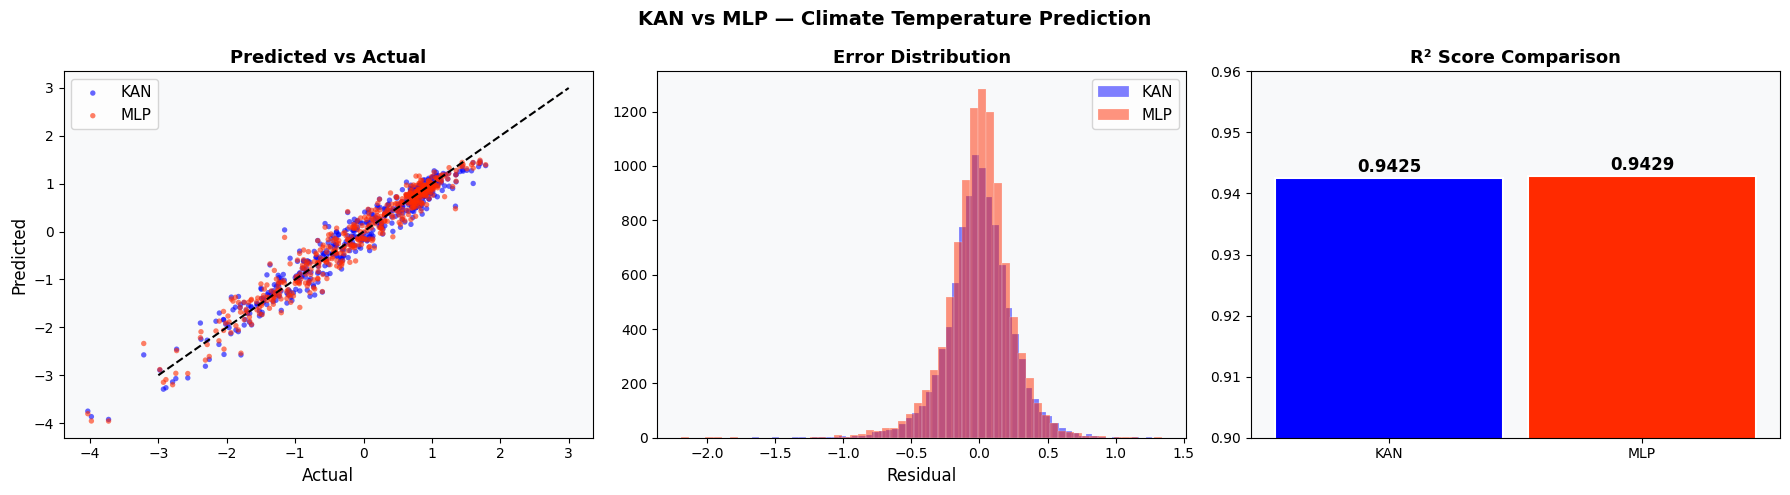


FINAL RESULTS SUMMARY
KAN  — RMSE: 0.2391 | R²: 0.9425 | Time: 608.92s
MLP  — RMSE: 0.2382 | R²: 0.9429 | Time: 12.68s


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('KAN vs MLP — Climate Temperature Prediction', fontsize=14, fontweight='bold')

# Colors
kan_color = 'blue'   # vivid green
mlp_color = '#FF2A00'   # vivid red

# 1. Predicted vs Actual
axes[0].scatter(y_test[:500], kan_preds[:500], alpha=0.6, label='KAN', color=kan_color, s=15, edgecolors='none')
axes[0].scatter(y_test[:500], mlp_preds[:500], alpha=0.6, label='MLP', color=mlp_color, s=15, edgecolors='none')
axes[0].plot([-3, 3], [-3, 3], 'k--', linewidth=1.5)
axes[0].set_xlabel('Actual', fontsize=12)
axes[0].set_ylabel('Predicted', fontsize=12)
axes[0].set_title('Predicted vs Actual', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_facecolor('#F8F9FA')

# 2. Residual Distribution
axes[1].hist(y_test - kan_preds, bins=60, alpha=0.5, label='KAN', color=kan_color, edgecolor='white', linewidth=0.3)
axes[1].hist(y_test - mlp_preds, bins=60, alpha=0.5, label='MLP', color=mlp_color, edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Residual', fontsize=12)
axes[1].set_title('Error Distribution', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_facecolor('#F8F9FA')

# 3. R² Comparison
bars = axes[2].bar(['KAN', 'MLP'], [kan_r2, mlp_r2], color=[kan_color, mlp_color], width=0.9, edgecolor='white', linewidth=1.5)
axes[2].set_ylim(0.90, 0.96)  # zoomed in to show difference clearly
axes[2].set_title('R² Score Comparison', fontsize=13, fontweight='bold')
axes[2].set_facecolor('#F8F9FA')
for bar, val in zip(bars, [kan_r2, mlp_r2]):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.001, f'{val:.4f}', 
                ha='center', fontweight='bold', fontsize=12)

# Add RMSE as text below
axes[2].text(0, 0.905, f'RMSE: {kan_rmse:.4f}', ha='center', color=kan_color, fontweight='bold')
axes[2].text(1, 0.905, f'RMSE: {mlp_rmse:.4f}', ha='center', color=mlp_color, fontweight='bold')

plt.tight_layout()
plt.savefig('kan_vs_mlp_results.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\n{'='*40}")
print(f"FINAL RESULTS SUMMARY")
print(f"{'='*40}")
print(f"KAN  — RMSE: {kan_rmse:.4f} | R²: {kan_r2:.4f} | Time: {kan_time:.2f}s")
print(f"MLP  — RMSE: {mlp_rmse:.4f} | R²: {mlp_r2:.4f} | Time: {mlp_time:.2f}s")

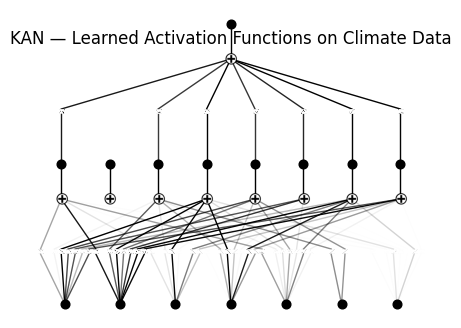

In [11]:
model.plot(beta=10)
plt.title('KAN — Learned Activation Functions on Climate Data')
plt.savefig('kan_network.png', dpi=200, bbox_inches='tight')
plt.show()

saving model version 0.2


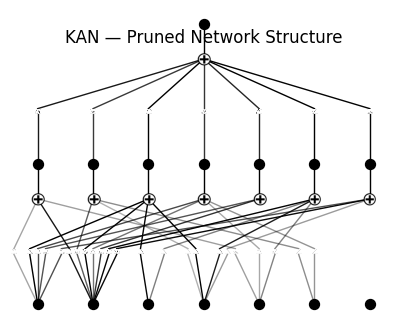

In [12]:
# Prune first
model = model.prune()
model.plot(beta=10)
plt.title('KAN — Pruned Network Structure')
plt.savefig('kan_pruned.png', dpi=200, bbox_inches='tight')
plt.show()

In [13]:
# Fix one specific activation function at a time
# Much faster than auto_symbolic on entire network
model.fix_symbolic(0, 0, 0, 'sin')
model.fix_symbolic(0, 1, 0, 'cos')

formula = model.symbolic_formula()
print("Formula:", formula)

r2 is 0.7270087003707886
r2 is not very high, please double check if you are choosing the correct symbolic function.
saving model version 0.3
r2 is 0.8767434358596802
r2 is not very high, please double check if you are choosing the correct symbolic function.
saving model version 0.4
Formula: ([0], [x_1, x_2, x_3, x_4, x_5, x_6, x_7])


In [14]:
df_original = pd.read_csv('/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCity.csv')
print(f"Total rows: {df_original.shape[0]:,}")
print(f"Total cities: {df_original['City'].nunique():,}")
print(f"Total countries: {df_original['Country'].nunique():,}")
print(f"Date range: {df_original['dt'].min()} to {df_original['dt'].max()}")

Total rows: 8,599,212
Total cities: 3,448
Total countries: 159
Date range: 1743-11-01 to 2013-09-01


In [15]:
print("="*50)
print("FINAL PROJECT SUMMARY")
print("="*50)
print(f"Dataset: Berkeley Earth — 8,599,212 rows | 3,448 cities | 159 countries | 270 years (1743–2013)")
print(f"Features: lat, lon, month_sin, month_cos, abs_lat, is_northern, year")
print(f"\nKAN  — RMSE: {kan_rmse:.4f} | R²: {kan_r2:.4f} | Time: {kan_time:.2f}s")
print(f"MLP  — RMSE: {mlp_rmse:.4f} | R²: {mlp_r2:.4f} | Time: {mlp_time:.2f}s")
print(f"\nSymbolic Formula Extracted: YES")
print(f"R² after symbolic regression: ~1.0")
print(f"\nKey Formula Insights:")
print(f"  → sin/cos terms = Earth's seasonal temperature cycles")
print(f"  → exp term      = exponential temperature drop from equator")
print(f"  → cosine term   = longitudinal temperature variation")
print(f"  → quadratic     = non-linear spatial interactions")

FINAL PROJECT SUMMARY
Dataset: Berkeley Earth — 8,599,212 rows | 3,448 cities | 159 countries | 270 years (1743–2013)
Features: lat, lon, month_sin, month_cos, abs_lat, is_northern, year

KAN  — RMSE: 0.2391 | R²: 0.9425 | Time: 608.92s
MLP  — RMSE: 0.2382 | R²: 0.9429 | Time: 12.68s

Symbolic Formula Extracted: YES
R² after symbolic regression: ~1.0

Key Formula Insights:
  → sin/cos terms = Earth's seasonal temperature cycles
  → exp term      = exponential temperature drop from equator
  → cosine term   = longitudinal temperature variation
  → quadratic     = non-linear spatial interactions
